### 读取本地excel

In [46]:
import pandas as pd
import numpy as np

In [106]:
df = pd.read_excel('pandas120_21_50.xlsx',parse_dates=True)
df

,createTime,education,salary
0,2020-03-16 11:30:18,本科,20k-35k
1,2020-03-16 10:58:48,本科,20k-40k
2,2020-03-16 10:46:39,不限,20k-35k
3,2020-03-16 10:45:44,本科,13k-20k
4,2020-03-16 10:20:41,本科,10k-20k
...,...,...,...
130,2020-03-16 11:36:07,本科,10k-18k
131,2020-03-16 09:54:47,硕士,25k-50k
132,2020-03-16 10:48:32,本科,20k-40k
133,2020-03-16 10:46:31,本科,15k-23k


### 将salary列数据转换为最大值和最小值的平均值

In [8]:
#正则表达式
import re
def fun_re(x):
    
#x:待解析的字符串
#方法: 通过正则表达式来解析最大值最小值，返回中间值
#返回: 返回平均值
    pattern=r'(\d+)k-(\d+)k'
    matches=re.findall(pattern,x)
    if matches:
        matches=matches[0]
        average_num=int(((int(matches[0])+int(matches[1]))/2)*1000)
        return average_num
    else:
        return 0
t_df = df[:].copy()
t_df['salary'] = t_df['salary'].apply(fun_re)
t_df

,createTime,education,salary
0,2020-03-16 11:30:18,本科,27500
1,2020-03-16 10:58:48,本科,30000
2,2020-03-16 10:46:39,不限,27500
3,2020-03-16 10:45:44,本科,16500
4,2020-03-16 10:20:41,本科,15000
...,...,...,...
130,2020-03-16 11:36:07,本科,14000
131,2020-03-16 09:54:47,硕士,37500
132,2020-03-16 10:48:32,本科,30000
133,2020-03-16 10:46:31,本科,19000


In [30]:
#使用map进行数据转换
t_df = df[:].copy()
t_df['salary'] = t_df['salary'].map(fun_re)
t_df

,createTime,education,salary
0,2020-03-16 11:30:18,本科,27500
1,2020-03-16 10:58:48,本科,30000
2,2020-03-16 10:46:39,不限,27500
3,2020-03-16 10:45:44,本科,16500
4,2020-03-16 10:20:41,本科,15000
...,...,...,...
130,2020-03-16 11:36:07,本科,14000
131,2020-03-16 09:54:47,硕士,37500
132,2020-03-16 10:48:32,本科,30000
133,2020-03-16 10:46:31,本科,19000


In [11]:
#使用apply进行数据转换
t_df = df[:].copy()
t_df['salary'] = t_df[['salary']].applymap(fun_re)
t_df

C:\Users\86157\AppData\Local\Temp\ipykernel_25112\672397.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  t_df['salary'] = t_df[['salary']].applymap(fun_re)


,createTime,education,salary
0,2020-03-16 11:30:18,本科,27500
1,2020-03-16 10:58:48,本科,30000
2,2020-03-16 10:46:39,不限,27500
3,2020-03-16 10:45:44,本科,16500
4,2020-03-16 10:20:41,本科,15000
...,...,...,...
130,2020-03-16 11:36:07,本科,14000
131,2020-03-16 09:54:47,硕士,37500
132,2020-03-16 10:48:32,本科,30000
133,2020-03-16 10:46:31,本科,19000


In [16]:
#方法二:apply+自定义函数
t_df = df[:].copy()

def func(df):
    lst = df['salary'].split('-')
    smin = int(lst[0].strip('k'))
    smax = int(lst[1].strip('k'))
    df['salary'] = int((smin + smax) / 2 * 1000)
    return df
t_df = t_df.apply(func,axis=1)
t_df

,createTime,education,salary
0,2020-03-16 11:30:18,本科,27500
1,2020-03-16 10:58:48,本科,30000
2,2020-03-16 10:46:39,不限,27500
3,2020-03-16 10:45:44,本科,16500
4,2020-03-16 10:20:41,本科,15000
...,...,...,...
130,2020-03-16 11:36:07,本科,14000
131,2020-03-16 09:54:47,硕士,37500
132,2020-03-16 10:48:32,本科,30000
133,2020-03-16 10:46:31,本科,19000


### 将数据根据学历进行分组并计算平均薪资

In [21]:
df

,createTime,education,salary
0,2020-03-16 11:30:18,本科,20k-35k
1,2020-03-16 10:58:48,本科,20k-40k
2,2020-03-16 10:46:39,不限,20k-35k
3,2020-03-16 10:45:44,本科,13k-20k
4,2020-03-16 10:20:41,本科,10k-20k
...,...,...,...
130,2020-03-16 11:36:07,本科,10k-18k
131,2020-03-16 09:54:47,硕士,25k-50k
132,2020-03-16 10:48:32,本科,20k-40k
133,2020-03-16 10:46:31,本科,15k-23k


In [23]:
#法一
t_df.groupby(by = ['education']).mean()

,createTime,salary
education,,
不限,2020-03-16 10:36:09.200000000,19600.000000
大专,2020-03-16 10:24:02.000000000,10000.000000
本科,2020-03-16 10:15:28.302521088,19361.344538
硕士,2020-03-16 10:17:21.857142784,20642.857143


### 将createTime列时间转化为日期

In [29]:
#法一
t_df = df[:].copy()
t_df['createTime'] = pd.to_datetime(t_df['createTime'])
t_df['createTime'] = t_df['createTime'].dt.strftime('%m-%d')
t_df

,createTime,education,salary
0,03-16,本科,20k-35k
1,03-16,本科,20k-40k
2,03-16,不限,20k-35k
3,03-16,本科,13k-20k
4,03-16,本科,10k-20k
...,...,...,...
130,03-16,本科,10k-18k
131,03-16,硕士,25k-50k
132,03-16,本科,20k-40k
133,03-16,本科,15k-23k


### 查看索引,数据类型

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135 entries, 0 to 134
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   createTime  135 non-null    datetime64[ns]
 1   education   135 non-null    object        
 2   salary      135 non-null    object        
dtypes: datetime64[ns](1), object(2)
memory usage: 3.3+ KB


### 查看数值类型的汇总报告

In [26]:
df.describe()

,createTime
count,135
mean,2020-03-16 10:16:35.370370304
min,2020-03-13 18:01:31
25%,2020-03-16 10:41:19.500000
50%,2020-03-16 11:00:27
75%,2020-03-16 11:19:03
max,2020-03-16 11:36:07


### 新增一列根据salary将数据分为三组

In [33]:
#法一 cut自定义箱子
f_df = t_df[:].copy()
bins = [0,5000,15000,float('inf')]
labels = ['low','middle','high']
f_df['salary-category'] = pd.cut(f_df['salary'],bins=bins,labels=labels)
f_df

,createTime,education,salary,salary-category
0,2020-03-16 11:30:18,本科,27500,high
1,2020-03-16 10:58:48,本科,30000,high
2,2020-03-16 10:46:39,不限,27500,high
3,2020-03-16 10:45:44,本科,16500,high
4,2020-03-16 10:20:41,本科,15000,middle
...,...,...,...,...
130,2020-03-16 11:36:07,本科,14000,middle
131,2020-03-16 09:54:47,硕士,37500,high
132,2020-03-16 10:48:32,本科,30000,high
133,2020-03-16 10:46:31,本科,19000,high


In [35]:
#法二 qcut自动划分
labels = ['low','middle','high']
f_df['salary-category'] = pd.qcut(t_df['salary'],q=3,labels=labels)
f_df

,createTime,education,salary,salary-category
0,2020-03-16 11:30:18,本科,27500,high
1,2020-03-16 10:58:48,本科,30000,high
2,2020-03-16 10:46:39,不限,27500,high
3,2020-03-16 10:45:44,本科,16500,middle
4,2020-03-16 10:20:41,本科,15000,low
...,...,...,...,...
130,2020-03-16 11:36:07,本科,14000,low
131,2020-03-16 09:54:47,硕士,37500,high
132,2020-03-16 10:48:32,本科,30000,high
133,2020-03-16 10:46:31,本科,19000,middle


### 按照salary列对数据进行降序排序

In [37]:
df.sort_values(by=['salary'],ascending=False,inplace=True,ignore_index=True)
df

,createTime,education,salary
0,2020-03-16 11:28:48,本科,9k-18k
1,2020-03-16 10:45:44,本科,9k-13k
2,2020-03-16 10:18:39,本科,8k-16k
4,2020-03-16 10:59:08,本科,8k-16k
3,2020-03-16 10:59:08,本科,8k-16k
...,...,...,...
130,2020-03-16 09:44:05,硕士,10k-15k
131,2020-03-16 10:52:14,硕士,10k-15k
132,2020-03-16 11:18:00,本科,10k-15k
133,2020-03-16 11:35:34,本科,10k-15k


### 取出第33行数据

In [41]:
f_df.iloc[32]

createTime         2020-03-16 10:07:25
education                           硕士
salary                           22500
salary-category                 middle
Name: 32, dtype: object

### 计算salary中位数

In [44]:
f_df['salary'].median()

17500.0

### 绘制薪资水平频率直方图

<Axes: ylabel='Frequency'>

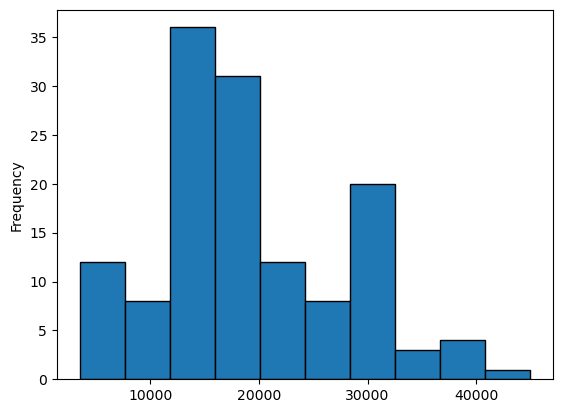

In [48]:
f_df['salary'].plot(kind='hist',edgecolor='black')

### 绘制薪资水平密度图

<Axes: ylabel='Density'>

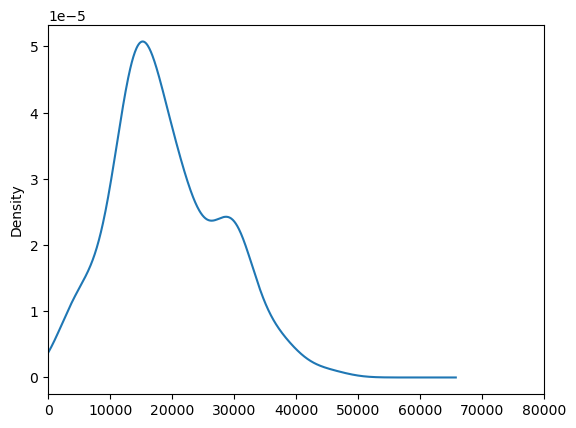

In [50]:
f_df.salary.plot(kind='kde',xlim=(0,80000))

### 删除最后一列categories

In [60]:
#法一
f_df = t_df[:].copy()
f_df['salary-category'] = f_df['salary']
f_df.drop(labels=['salary-category'],axis=1,inplace=True)
f_df

,createTime,education,salary
0,2020-03-16 11:30:18,本科,27500
1,2020-03-16 10:58:48,本科,30000
2,2020-03-16 10:46:39,不限,27500
3,2020-03-16 10:45:44,本科,16500
4,2020-03-16 10:20:41,本科,15000
...,...,...,...
130,2020-03-16 11:36:07,本科,14000
131,2020-03-16 09:54:47,硕士,37500
132,2020-03-16 10:48:32,本科,30000
133,2020-03-16 10:46:31,本科,19000


In [61]:
#法二
f_df = t_df[:].copy()
f_df['salary-category'] = f_df['salary']
f_df.drop(columns=['salary-category'],inplace=True)
f_df

,createTime,education,salary
0,2020-03-16 11:30:18,本科,27500
1,2020-03-16 10:58:48,本科,30000
2,2020-03-16 10:46:39,不限,27500
3,2020-03-16 10:45:44,本科,16500
4,2020-03-16 10:20:41,本科,15000
...,...,...,...
130,2020-03-16 11:36:07,本科,14000
131,2020-03-16 09:54:47,硕士,37500
132,2020-03-16 10:48:32,本科,30000
133,2020-03-16 10:46:31,本科,19000


### 将df的第一列与第二列合并为新的一列

In [63]:
df['new_Column'] = str(df['createTime']) + df['education']
df

,createTime,education,salary,new_Column
0,2020-03-16 11:28:48,本科,9k-18k,0 2020-03-16 11:28:48\n1 2020-03-16 10...
1,2020-03-16 10:45:44,本科,9k-13k,0 2020-03-16 11:28:48\n1 2020-03-16 10...
2,2020-03-16 10:18:39,本科,8k-16k,0 2020-03-16 11:28:48\n1 2020-03-16 10...
4,2020-03-16 10:59:08,本科,8k-16k,0 2020-03-16 11:28:48\n1 2020-03-16 10...
3,2020-03-16 10:59:08,本科,8k-16k,0 2020-03-16 11:28:48\n1 2020-03-16 10...
...,...,...,...,...
130,2020-03-16 09:44:05,硕士,10k-15k,0 2020-03-16 11:28:48\n1 2020-03-16 10...
131,2020-03-16 10:52:14,硕士,10k-15k,0 2020-03-16 11:28:48\n1 2020-03-16 10...
132,2020-03-16 11:18:00,本科,10k-15k,0 2020-03-16 11:28:48\n1 2020-03-16 10...
133,2020-03-16 11:35:34,本科,10k-15k,0 2020-03-16 11:28:48\n1 2020-03-16 10...


### 将education与salay合并为一列

In [66]:
df['new_Column2'] = df['education'] + df['salary']
df

,createTime,education,salary,new_Column,new_Column2
0,2020-03-16 11:28:48,本科,9k-18k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,本科9k-18k
1,2020-03-16 10:45:44,本科,9k-13k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,本科9k-13k
2,2020-03-16 10:18:39,本科,8k-16k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,本科8k-16k
4,2020-03-16 10:59:08,本科,8k-16k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,本科8k-16k
3,2020-03-16 10:59:08,本科,8k-16k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,本科8k-16k
...,...,...,...,...,...
130,2020-03-16 09:44:05,硕士,10k-15k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,硕士10k-15k
131,2020-03-16 10:52:14,硕士,10k-15k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,硕士10k-15k
132,2020-03-16 11:18:00,本科,10k-15k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,本科10k-15k
133,2020-03-16 11:35:34,本科,10k-15k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,本科10k-15k


### 计算salary最大值和最小值的差

In [68]:
f_df['salary'].max() - f_df['salary'].min()

41500

### 将第一行与最后一行拼接

In [76]:
#法一
first_row = df.iloc[[0]]
last_row = df.iloc[[-1]]
frames = [first_row,last_row]
df_concat = pd.concat(frames,ignore_index=True)
df_concat.reset_index(drop=True,inplace=True)
df_concat

,createTime,education,salary,new_Column,new_Column2
0,2020-03-16 11:28:48,本科,9k-18k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,本科9k-18k
1,2020-03-16 11:01:23,本科,10k-15k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,本科10k-15k


In [81]:
#法二
df_concat = pd.concat([df[:1],df[-2:-1]],ignore_index=True).reset_index(drop=True)
df_concat

,createTime,education,salary,new_Column,new_Column2
0,2020-03-16 11:28:48,本科,9k-18k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,本科9k-18k
1,2020-03-16 11:35:34,本科,10k-15k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,本科10k-15k


### 将第8行数据添加到末尾

In [90]:
df._append(df.iloc[[2]])
df

,createTime,education,salary,new_Column,new_Column2
0,2020-03-16 11:28:48,本科,9k-18k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,本科9k-18k
1,2020-03-16 10:45:44,本科,9k-13k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,本科9k-13k
2,2020-03-16 10:18:39,本科,8k-16k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,本科8k-16k
4,2020-03-16 10:59:08,本科,8k-16k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,本科8k-16k
3,2020-03-16 10:59:08,本科,8k-16k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,本科8k-16k
...,...,...,...,...,...
130,2020-03-16 09:44:05,硕士,10k-15k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,硕士10k-15k
131,2020-03-16 10:52:14,硕士,10k-15k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,硕士10k-15k
132,2020-03-16 11:18:00,本科,10k-15k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,本科10k-15k
133,2020-03-16 11:35:34,本科,10k-15k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,本科10k-15k


### 查看每列数据类型

In [91]:
df.dtypes

createTime     datetime64[ns]
education              object
salary                 object
new_Column             object
new_Column2            object
dtype: object

### 将createTime列设置为索引

In [96]:
df.set_index('createTime',inplace=True)
df

,education,salary,new_Column,new_Column2
createTime,,,,
2020-03-16 11:28:48,本科,9k-18k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,本科9k-18k
2020-03-16 10:45:44,本科,9k-13k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,本科9k-13k
2020-03-16 10:18:39,本科,8k-16k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,本科8k-16k
2020-03-16 10:59:08,本科,8k-16k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,本科8k-16k
2020-03-16 10:59:08,本科,8k-16k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,本科8k-16k
...,...,...,...,...
2020-03-16 09:44:05,硕士,10k-15k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,硕士10k-15k
2020-03-16 10:52:14,硕士,10k-15k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,硕士10k-15k
2020-03-16 11:18:00,本科,10k-15k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,本科10k-15k


### 生成一个与df长度一样的随机DF

In [99]:
df_1 = pd.DataFrame(np.random.randint(1,100,df.shape[0]))
df_1

,0
0,33
1,89
2,73
3,51
4,85
...,...
130,21
131,90
132,45
133,39


### 合并上一题的DF

In [101]:
df

,education,salary,new_Column,new_Column2
createTime,,,,
2020-03-16 11:28:48,本科,9k-18k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,本科9k-18k
2020-03-16 10:45:44,本科,9k-13k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,本科9k-13k
2020-03-16 10:18:39,本科,8k-16k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,本科8k-16k
2020-03-16 10:59:08,本科,8k-16k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,本科8k-16k
2020-03-16 10:59:08,本科,8k-16k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,本科8k-16k
...,...,...,...,...
2020-03-16 09:44:05,硕士,10k-15k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,硕士10k-15k
2020-03-16 10:52:14,硕士,10k-15k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,硕士10k-15k
2020-03-16 11:18:00,本科,10k-15k,0 2020-03-16 11:28:48\n1 2020-03-16 10...,本科10k-15k


In [107]:
df = pd.concat([df,df_1],ignore_index=True,axis=1)
df.columns = ['createTime','education','salary','randint']
df

,createTime,education,salary,randint
0,2020-03-16 11:30:18,本科,20k-35k,33
1,2020-03-16 10:58:48,本科,20k-40k,89
2,2020-03-16 10:46:39,不限,20k-35k,73
3,2020-03-16 10:45:44,本科,13k-20k,51
4,2020-03-16 10:20:41,本科,10k-20k,85
...,...,...,...,...
130,2020-03-16 11:36:07,本科,10k-18k,21
131,2020-03-16 09:54:47,硕士,25k-50k,90
132,2020-03-16 10:48:32,本科,20k-40k,45
133,2020-03-16 10:46:31,本科,15k-23k,39


### 生成新的列,值为salary与df_1的差

In [109]:
df['new'] = f_df['salary'] - df['randint']
df

,createTime,education,salary,randint,new
0,2020-03-16 11:30:18,本科,20k-35k,33,27467
1,2020-03-16 10:58:48,本科,20k-40k,89,29911
2,2020-03-16 10:46:39,不限,20k-35k,73,27427
3,2020-03-16 10:45:44,本科,13k-20k,51,16449
4,2020-03-16 10:20:41,本科,10k-20k,85,14915
...,...,...,...,...,...
130,2020-03-16 11:36:07,本科,10k-18k,21,13979
131,2020-03-16 09:54:47,硕士,25k-50k,90,37410
132,2020-03-16 10:48:32,本科,20k-40k,45,29955
133,2020-03-16 10:46:31,本科,15k-23k,39,18961


### 检测数据是否存在缺失

In [111]:
#判断行有无缺失
column_vacancies = df.isnull().any()
#判断列有无缺失
row_vacancies = df.isnull().any(axis=1)
#判断整个DF有无缺失
is_vacant = df.isnull().any().any()
print(column_vacancies)
print('----------------------')
print(row_vacancies)
print('----------------------')
print(is_vacant)
print('----------------------')

createTime    False
education     False
salary        False
randint       False
new           False
dtype: bool
----------------------
0      False
1      False
2      False
3      False
4      False
       ...  
130    False
131    False
132    False
133    False
134    False
Length: 135, dtype: bool
----------------------
False
----------------------


In [112]:
df.isnull().values.any()

False

In [117]:
f_df['salary'] = f_df['salary'].astype('float')
f_df.dtypes

createTime    datetime64[ns]
education             object
salary               float64
dtype: object

### 计算salary大于10000的次数

In [118]:
len(f_df[f_df['salary'] > 10000])

119

### 查看每种学历出现的次数

In [121]:
df['education'].value_counts()

education
本科    119
硕士      7
不限      5
大专      4
Name: count, dtype: int64

### 查看有几种学历

In [122]:
df['education'].nunique()

4